# 01 — When the coin has memory

Notebook 00 ended on a question: *what changes when the coin's probability has a memory of previous
tosses?*

Here is the sharpest form of that question. Take two binary records with **exactly the same number
of heads**, differing only in the **order** the heads arrive. Any test built on the count alone must
call them identical, because the count is the same number. Yet one of them was produced by a process
with memory and the other was not, and that difference is physical — it is the difference between a
sensor whose *balance* has shifted and one whose *correlation time* has.

Nothing is simplified and then corrected. The coin here is the same Bernoulli observation as in
notebook 00, and the memory is the discrete counterpart of the Ornstein–Uhlenbeck process the
project actually uses.


In [1]:
import io, math, os, sys
from pathlib import Path

import numpy as np
from scipy.stats import binom, binomtest, norm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Import the project's tested functions rather than restating the formulas here.
ROOT = Path(os.environ["SID_ROOT"]) if os.environ.get("SID_ROOT") else Path.cwd()
while not (ROOT / "analysis" / "lib").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "analysis" / "lib").is_dir():
    raise RuntimeError("run this notebook from inside the repository, or set SID_ROOT")
sys.path.insert(0, str(ROOT / "analysis" / "lib"))
from sid_lib import simulate, rk_exact, hmm_rate, I_ext_exact, INK, SEA, SIG, STONE, PARCH

plt.rcParams.update({"font.family": "serif", "figure.dpi": 130,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
SEED = 20260907           # every random result below is reproducible from this

try:
    from IPython.display import Image, display
    _INLINE = True
except ImportError:
    _INLINE = False

def show(fig):
    if _INLINE:
        buf = io.BytesIO(); fig.savefig(buf, format="png", bbox_inches="tight")
        display(Image(data=buf.getvalue()))
    plt.close(fig)

print("[env] project root:", ROOT.name)
print("[env] python", ".".join(map(str, sys.version_info[:3])), "| numpy", np.__version__)

[env] project root: signals-in-darkness
[env] python 3.9.7 | numpy 1.23.5


## 1. Two records, one head count

`simulate` draws a binary record whose success probability is driven by a hidden phase following an
AR(1) recursion — the discrete counterpart of an Ornstein–Uhlenbeck process. The parameter `a` is
the per-toss memory: `a = 0` forgets immediately, `a` near 1 remembers for a long time.

The second record is simply the **first one shuffled**. Same symbols, same count, order destroyed.


In [2]:
C, s = 0.4, 0.5                 # contrast and phase amplitude (radians)
TAU_C = 20.0                    # correlation time, in tosses
a = math.exp(-1.0 / TAU_C)      # per-toss memory of the hidden phase
N = 4000
THETA_MID = math.pi / 2         # mid-fringe readout

rng = np.random.default_rng(SEED)
y_mem = simulate(C, s, THETA_MID, a, N, rng)          # has memory
y_shuf = rng.permutation(y_mem)                        # identical multiset, order destroyed

k_mem, k_shuf = int(y_mem.sum()), int(y_shuf.sum())
print(f"memory record : {k_mem} heads in {N} tosses")
print(f"shuffled      : {k_shuf} heads in {N} tosses")
print(f"identical count: {k_mem == k_shuf}")

for name, y in (("memory", y_mem), ("shuffled", y_shuf)):
    r = binomtest(int(y.sum()), N, 0.5)
    print(f"  {name:>8}: binomial test against a fair coin, p = {r.pvalue:.4f}")

memory record : 2034 heads in 4000 tosses
shuffled      : 2034 heads in 4000 tosses
identical count: True
    memory: binomial test against a fair coin, p = 0.2894
  shuffled: binomial test against a fair coin, p = 0.2894


> **worked example** — the two records have the **same** head count, so every count-based
> statistic returns the **same** answer on both, to the last digit. This is not an approximation or
> a small effect: the count is a single number, and it is the same number.

That is a statement about these two *realised* records. It is tempting to slide from it to a claim
about the *processes* that made them — and that slide is wrong, so it is worth taking slowly.

At mid-fringe the marginal probability of heads is exactly one half, whatever the contrast and
whatever the amplitude: the hidden phase pushes it up as often as down. But fixing the **mean** of
the count does not fix its **distribution**. Positive correlations make heads arrive in clusters,
and clustering makes the total *more variable* than a fair coin's, even though it is not biased.


In [3]:
# The mean is fixed at 1/2; the variance is not. For a stationary binary record,
#   Var(K) = (N/4) * [ 1 + 2 * sum_k (1 - k/N) r_k ]
# and the bracket is the variance-inflation factor. r_k is imported, not restated.
kk = np.arange(1, N)
vif = 1 + 2 * np.sum((1 - kk / N) * rk_exact(C, s, a ** kk))
print(f"variance-inflation factor of the head count: {vif:.4f}")
print(f"  sd of K: {math.sqrt(N/4):.2f} for a fair coin -> {math.sqrt(N/4*vif):.2f} with memory")
print()

# An exact two-sided count-only test, calibrated on the fair-coin null.
lo = int(binom.ppf(0.025, N, 0.5)); hi = int(binom.isf(0.025, N, 0.5))
alpha = float(binom.cdf(lo - 1, N, 0.5) + binom.sf(hi, N, 0.5))
R_POWER = 800
rng_pow = np.random.default_rng(SEED + 1)
counts = np.array([simulate(C, s, THETA_MID, a, N, rng_pow).sum() for _ in range(R_POWER)])
power = float(((counts < lo) | (counts > hi)).mean())
se = math.sqrt(power * (1 - power) / R_POWER)
print(f"reject the fair coin when K < {lo} or K > {hi}")
print(f"  false-alarm rate on the null (exact): {100*alpha:.2f} %")
print(f"  power against the correlated process ({R_POWER} runs): "
      f"{100*power:.1f} % +- {100*se:.1f} pp")
print()

# Does that power grow with N? No -- and this is the part that is easy to get wrong.
# Both null and alternative centre K at N/2 and both widths scale as sqrt(N), so the
# standardised count has null N(0,1) and alternative N(0, V_inf) whatever N is.
V_inf = 1 + 2 * float(np.sum(rk_exact(C, s, a ** np.arange(1, 200_000))))
z = norm.isf(0.025)
print(f"V_inf = 1 + 2*sum_k r_k = {V_inf:.4f}")
print(f"  asymptotic power = 2*Phi(-{z:.2f}/sqrt(V_inf)) = {100*2*norm.cdf(-z/math.sqrt(V_inf)):.2f} %")
print(f"  the {100*power:.0f} % measured at N={N} is already essentially that limit")
print()
print(f"V_inf is 1 + delta(0), where delta(0) = 2*sum_k r_k is the spectral perturbation")
print(f"the project uses elsewhere as a validity criterion: delta(0) = {V_inf-1:.4f} here")

variance-inflation factor of the head count: 2.2130
  sd of K: 31.62 for a fair coin -> 47.04 with memory



reject the fair coin when K < 1938 or K > 2062
  false-alarm rate on the null (exact): 4.81 %
  power against the correlated process (800 runs): 18.9 % +- 1.4 pp

V_inf = 1 + 2*sum_k r_k = 2.2192
  asymptotic power = 2*Phi(-1.96/sqrt(V_inf)) = 18.83 %
  the 19 % measured at N=4000 is already essentially that limit

V_inf is 1 + delta(0), where delta(0) = 2*sum_k r_k is the spectral perturbation
the project uses elsewhere as a validity criterion: delta(0) = 1.2192 here


> **worked example** — the count-only test is **not** powerless against the memory. It rejects the
> fair coin about 19 % of the time at a 5 % false-alarm rate, because the correlations roughly double
> the variance of the count.

> **worked example** — but that power does **not** grow with the record. Both the fair coin and the
> correlated process centre the count at $N/2$, and both widths scale as $\sqrt N$, so the
> standardised count has an $N(0,1)$ null and an $N(0,V_\infty)$ alternative *whatever* $N$ is. The
> nominal 5 % test therefore approaches $2\Phi(-1.96/\sqrt{V_\infty}) = 18.83\%$, not 100 %, and the
> value measured at $N = 4000$ is already essentially that limit. **Nonzero power means the statistic
> responds to the alternative; it does not imply that one total count becomes decisive as the record
> grows.**

> **worked example** — $V_\infty = 1 + \delta(0)$, where $\delta(0) = 2\sum_k r_k$ is the same spectral
> perturbation the project uses elsewhere as a validity criterion. The overdispersion of the coin's
> head count and the quantity that decides where a closed-form approximation stops being trustworthy
> are the same number.

So the honest statement has four parts, and they are easy to run together:

1. Two **realised** records with the same count are indistinguishable to every count-only statistic.
   That is exact, and it is what section 1 showed.
2. The correlated **process** still shifts the distribution of that count, through overdispersion.
   A count-only test therefore has real, if limited, power — and that power plateaus rather than
   rising towards certainty, because the alternative differs from the null in width and not in
   centre.
3. **Conditional on the count**, all the remaining evidence lies in the ordering.
4. The full ordered record carries information the count discards — which is what the rest of this
   notebook measures.

## 2. What the ordering shows

The statistic that *does* see the difference is the **lag correlation**: how much a toss tells you
about the toss `k` steps later. The project has a closed form for it, and the notebook imports that
formula rather than restating it.


In [4]:
def empirical_lag_corr(y, kmax):
    """Sample autocorrelation of a binary record. A plain estimator, not a project formula."""
    x = y.astype(float) - y.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-k], x[k:]) / denom for k in range(1, kmax + 1)])

KMAX = 60
lags = np.arange(1, KMAX + 1)

# rk_exact already returns a CORRELATION: the project normalises the covariance by the
# mid-fringe binary variance of 1/4 (this is the normalisation named in claim C02). It is
# not divided again here.
theory = rk_exact(C, s, a ** lags)

emp_mem = empirical_lag_corr(y_mem, KMAX)
emp_shuf = empirical_lag_corr(y_shuf, KMAX)

# The correlations are small -- about 0.03 at lag 1. The familiar 1/sqrt(N) scale is the
# spread of a sample correlation for an INDEPENDENT record; for a correlated one it is only
# an approximate reference, and it understates the true spread. It is used below to show the
# order of magnitude of the estimation noise, not as a standard error for this process.
N_LONG = 200_000
rng_long = np.random.default_rng(SEED + 2)
y_long = simulate(C, s, THETA_MID, a, N_LONG, rng_long)
emp_long = empirical_lag_corr(y_long, KMAX)

se_short, se_long = 1 / math.sqrt(N), 1 / math.sqrt(N_LONG)
print(f"approximate iid reference scale 1/sqrt(N): {se_short:.4f} at N={N}, "
      f"{se_long:.4f} at N={N_LONG}")
print("  (an iid yardstick, not a standard error for a correlated record -- it understates it)")
print()
print(f"{'lag':>4} {'exact (C02)':>12} {'N=200000':>10} {'N=4000':>9} {'shuffled':>10}")
for k in (1, 5, 10, 20, 40):
    print(f"{k:>4} {theory[k-1]:>12.4f} {emp_long[k-1]:>10.4f} "
          f"{emp_mem[k-1]:>9.4f} {emp_shuf[k-1]:>10.4f}")

approximate iid reference scale 1/sqrt(N): 0.0158 at N=4000, 0.0022 at N=200000
  (an iid yardstick, not a standard error for a correlated record -- it understates it)

 lag  exact (C02)   N=200000    N=4000   shuffled
   1       0.0299     0.0287    0.0360    -0.0246
   5       0.0244     0.0219    0.0570     0.0095
  10       0.0190     0.0155    0.0157     0.0107
  20       0.0115     0.0100    0.0322    -0.0128
  40       0.0042     0.0066    0.0412     0.0097


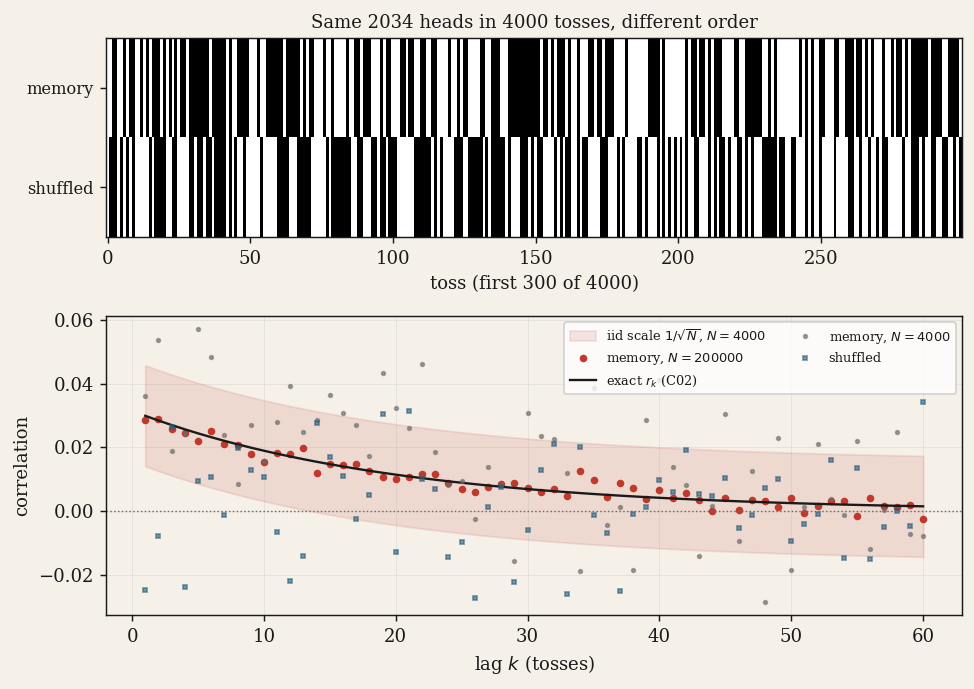

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(7.6, 5.4), facecolor=PARCH,
                         gridspec_kw={"height_ratios": [1, 1.5]})
for ax in axes:
    ax.set_facecolor(PARCH)

STRIP = 300
axes[0].imshow(np.vstack([y_mem[:STRIP], y_shuf[:STRIP]]), aspect="auto",
               cmap="binary", interpolation="nearest")
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["memory", "shuffled"], fontsize=9)
axes[0].set_xlabel(f"toss (first {STRIP} of {N})"); axes[0].grid(False)
axes[0].set_title(f"Same {k_mem} heads in {N} tosses, different order", fontsize=10)

axes[1].fill_between(lags, theory - se_short, theory + se_short, color=SIG, alpha=0.12,
                     label=rf"iid scale $1/\sqrt{{N}}$, $N={N}$")
axes[1].plot(lags, emp_long, "o", ms=3.2, color=SIG, label=f"memory, $N={N_LONG}$")
axes[1].plot(lags, theory, "-", color=INK, lw=1.3, label=r"exact $r_k$ (C02)")
axes[1].plot(lags, emp_mem, ".", ms=4.0, color=STONE, alpha=0.6, label=f"memory, $N={N}$")
axes[1].plot(lags, emp_shuf, "s", ms=2.6, color=SEA, alpha=0.6, label="shuffled")
axes[1].axhline(0, color=STONE, lw=0.8, ls=":")
axes[1].set_xlabel("lag $k$ (tosses)"); axes[1].set_ylabel("correlation")
axes[1].legend(fontsize=7.2, ncol=2)
fig.tight_layout(); show(fig)

> **C02 — result** — the sample lag correlations of a long memory record follow the project's exact
> mid-fringe form $r_k = \bar C^2 e^{-s^2}\sinh(s^2 a_k)$, while the shuffled record's scatter about
> zero. The two records are the same coin by the count and different processes by the ordering.

> **worked example** — at $N = 4000$ the estimate is buried in its own noise: the correlation is
> about $0.03$ against an iid reference scale of $1/\sqrt{N} \approx 0.016$, and for a correlated
> record the true spread is larger still. Only the $N = 200{,}000$ record shows the agreement
> clearly. This is why detecting a change in memory **can require long records in the
> weak-correlation regime** — not a general rule that memory is always slower, since the figure
> below shows the memory channel overtaking the balance channel once the correlation time is long
> enough. It is also why the project measures detection *delay* rather than asking whether a
> difference exists at all.

## 3. The hidden-process rate

Correlations show that the two records differ. To say *how much* a detector can extract from that
difference, the project uses the exact rate of the latent-AR(1) binary process — imported here as
`hmm_rate`, not restated.


In [6]:
TAUS = np.array([1.0, 2.0, 5.0, 10.0, 20.0, 50.0])
mid, ext = [], []
for tc in TAUS:
    a_tc = math.exp(-1.0 / tc)
    mid.append(hmm_rate(C, s, THETA_MID, a_tc, N=60_000, seed=11))
    # Single-shot contrast-loss divergence. This is the extremum's ONE-SHOT rate and does not
    # depend on tau_c. The extremum stream also carries a small correlation bonus, which is
    # NOT included here -- see claim C24, which is open.
    ext.append(I_ext_exact(C, s))

print(f"{'tau_c':>7} {'mid-fringe (memory)':>21} {'extremum single-shot':>22}")
for tc, m, e in zip(TAUS, mid, ext):
    print(f"{tc:>7.0f} {m:>21.3e} {e:>22.3e}")
print()
print("the extremum column omits its correlation bonus (C24, open), so it is a lower bound")
print("a memoryless mid-fringe record reduces to a fair coin, so its rate here is exactly 0")

  tau_c   mid-fringe (memory)   extremum single-shot
      1             7.745e-05              1.296e-03
      2             3.393e-04              1.296e-03
      5             7.819e-04              1.296e-03
     10             1.837e-03              1.296e-03
     20             3.154e-03              1.296e-03
     50             5.467e-03              1.296e-03

the extremum column omits its correlation bonus (C24, open), so it is a lower bound
a memoryless mid-fringe record reduces to a fair coin, so its rate here is exactly 0


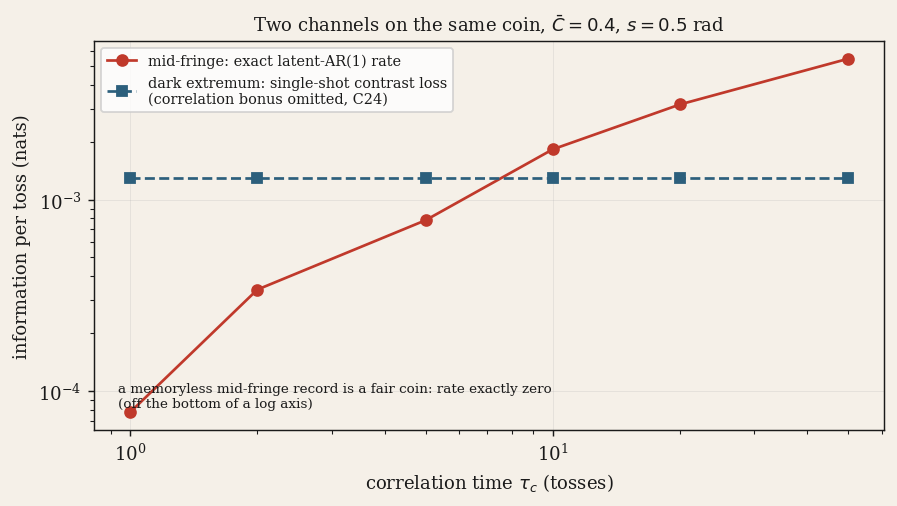

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.0), facecolor=PARCH); ax.set_facecolor(PARCH)
ax.plot(TAUS, mid, "o-", color=SIG, label="mid-fringe: exact latent-AR(1) rate")
ax.plot(TAUS, ext, "s--", color=SEA,
        label="dark extremum: single-shot contrast loss\n(correlation bonus omitted, C24)")
ax.text(0.03, 0.06, "a memoryless mid-fringe record is a fair coin: rate exactly zero\n"
        "(off the bottom of a log axis)", transform=ax.transAxes, fontsize=7.5, color=INK)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"correlation time $\tau_c$ (tosses)")
ax.set_ylabel("information per toss (nats)")
ax.set_title(rf"Two channels on the same coin, $\bar C={C}$, $s={s}$ rad", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout(); show(fig)

> **worked example** — the memory channel's rate **grows** with the correlation time, because a
> longer memory makes the ordering more predictable and so more informative. The extremum curve is
> drawn flat because it shows only the single-shot contrast-loss divergence, which does not depend
> on the correlation time.

> **C24 — open** — the extremum stream also carries a correlation bonus of its own, so the flat line
> is a lower bound rather than the whole story. The bonus enters at higher order and is small in
> this regime; the claim that it is at most 6 %, and only in the high-contrast, long-correlation-time
> corner, is **open** and not yet established.

The two curves cross. Where they cross is not a detail of this illustration — it is the project's
actual subject.


## 4. Two ways for a sensor to change

Notebook 00's coin could change in one way: the probability of heads moved. A coin with memory can
change in **two**, and they are physically distinct.

| what changed | what a detector should watch | in the physics |
|---|---|---|
| the **balance** — heads became more likely | the count | contrast loss at a fringe extremum |
| the **memory** — heads began to cluster | the lag correlations | temporal structure at mid-fringe |

A readout angle is a *choice* of which of these to listen to, and the choice sets what each one
hears **best**, not what it hears exclusively. The extremum is dominated by balance but is not
strictly deaf to ordering (C24). Mid-fringe is dominated by ordering but is not strictly deaf to the
count either, because clustering shows up as overdispersion. Which choice detects a given
disturbance faster depends on how long the memory lasts — and neither answer holds everywhere.


> **C05 — result** — for this binary-link model and the project's exact correlation-rate
> comparator, there is a sequential-information crossover between the two operating points: neither
> is universally better, and which one wins depends on the correlation time and the amplitude.

> **worked example** — the crossing visible in the figure above is that statement in miniature, at
> one contrast and one amplitude, computed here for teaching. The project's claim is the quantitative
> boundary, not the observation that a crossing exists.

## What this notebook established

- Two **realised** records can carry **identical counts** and **different memory**, and no count-only
  statistic can tell those two records apart.
- The correlated **process** is still visible in the count, through **overdispersion**: the
  correlations roughly double the variance, and a count-only test has about 19 % power here at a 5 %
  false-alarm rate. Limited power, not none — the distinction between a realised record and the
  process that generated it does real work.
- That power **plateaus at 18.83 %** however long the record gets, because the alternative differs
  from the null in width rather than in centre. Nonzero power means the statistic responds to the
  alternative; it does not mean one total count eventually becomes decisive.
- Conditional on the count, the remaining evidence lies entirely in the **ordering**, and the lag
  correlations of a long record follow the project's exact form.
- The information a detector extracts from ordering **grows** with the correlation time, while the
  single-shot contrast-loss rate does not — so the two channels cross.
- **A sensor can detect either a change in balance or a change in memory.**

That last sentence is the question notebook 02 opens: if the coin is really a quantum measurement,
what physically *is* the balance, what physically *is* the memory, and where exactly does the
crossing fall?
